In [ ]:
# Task 1

In [29]:
# import packages 
import scanpy as sc
import pandas as pd
# Data Processing
import pandas as pd
import numpy as np
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image

In [30]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_hvg_qc")

In [31]:
#Check the treatment condition
print(adata.obs["perturbation_2"].value_counts())

perturbation_2
IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64


In [32]:
# Train on 2000 highly variable genes
print(adata.var["highly_variable"].value_counts())

highly_variable
False    21711
True      2000
Name: count, dtype: int64


In [33]:
#Subset the data with only hvgs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(adata_hvg.shape)

(191174, 2000)


In [34]:
# Define the gene expression matrix as the input features for the classification model
X = adata_hvg.X

# Define the experimental condition (Control, IFNγ, or Co-culture)
# as the target variable to be predicted
y = adata_hvg.obs["perturbation_2"].values

In [35]:
#Split the dataset into train and test set 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
# Convert the target variable into a pandas Series
y = pd.Series(y)
# Display the number of cells belonging to each experimental condition
print(y.value_counts())
# Display the proportion of cells belonging to each experimental condition
print(y.value_counts(normalize=True))

IFNγ          74186
Co-culture    67093
Control       49895
Name: count, dtype: int64
IFNγ          0.388055
Co-culture    0.350953
Control       0.260993
Name: proportion, dtype: float64


In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Test a Random Forest model with manually selected parameters
# to get an initial idea of model performance and training time
# before performing further model optimization
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees in the forest
    max_depth=15,            # maximum depth of each tree
    min_samples_split=5,     # minimum samples required to split a node
    min_samples_leaf=2,      # minimum samples required in a leaf
    max_features="sqrt",     # number of genes considered at each split
    class_weight="balanced", # account for differences in class sizes
    random_state=42,         # ensure reproducible results
    n_jobs=1                 # use one CPU core
)

# Record the starting time to estimate how long model training takes
start = time.time()

# Train the Random Forest classifier on the training data
rf.fit(X_train, y_train)

# Record the finishing time
end = time.time()

# Print the training time in minutes
# to estimate the runtime of future model training
print(f"Training time: {(end - start) / 60:.2f} minutes")

# Predict the experimental condition of the test cells
y_pred = rf.predict(X_test)

# Evaluate the initial model using accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display precision, recall, and F1-score for each condition
print(classification_report(y_test, y_pred))

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Hyperparameter values to search
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ["sqrt", "log2", 0.2, 0.5]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,              # Number of random combinations to evaluate
    cv=3,
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=   5.3s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 5.7min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  10.8s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=   5.2s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 5.8min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  11.0s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=   5.2s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total tim

In [39]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.2, 'max_depth': 6}


In [101]:
# best hyperparameters 200 trees, 4 split min_samples_leaf = 4, max depth = 9, max_features : 0.2

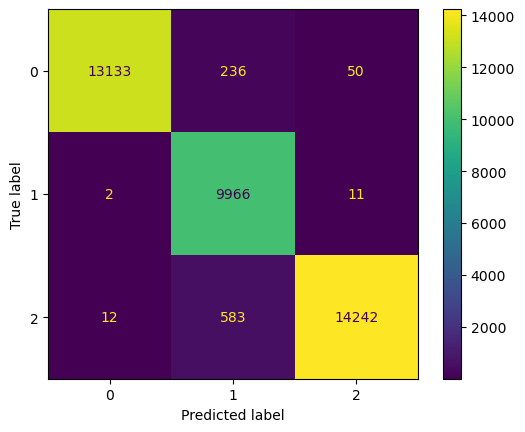

In [40]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();


In [41]:
# Calculate the overall classification accuracy by comparing
# the true test labels with the predicted labels
accuracy = accuracy_score(y_test, y_pred)

# Display the proportion of correctly classified test cells
print("Accuracy:", accuracy)

Accuracy: 0.9766182816790898


In [42]:
#For feature importance (genes names) check the column in adata_hvg
print(adata_hvg.var_names)

Index(['AADAC', 'AATBC', 'ABCB11', 'ABCB6', 'ABHD12B', 'ABL2', 'AC002310.2',
       'AC002347.1', 'AC002384.1', 'AC003092.1',
       ...
       'ZNF320', 'ZNF350-AS1', 'ZNF366', 'ZNF451-AS1', 'ZNF534', 'ZNF660',
       'ZNF728', 'ZNF763', 'ZNF80', 'ZSCAN5B'],
      dtype='object', name='gene_symbol', length=2000)


In [43]:
# Check the dimensions of the training data
print("X_train shape:", X_train.shape)

# Check the number of feature importance values returned by the Random Forest
# to confirm that there is one importance value for each input gene
print("Number of importances:", best_rf.feature_importances_.shape)

X_train shape: (152939, 2000)
Number of importances: (2000,)


In [44]:
import pandas as pd

# Best Random Forest model
best_rf = rand_search.best_estimator_

# Feature importance
gene_importance = pd.DataFrame({
    "Gene": adata_hvg.var_names,
    "Importance": best_rf.feature_importances_
})

# Sort by importance 
gene_importance = gene_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 100 genes
top100 = gene_importance.head(100)
print(top100)

# Save top 100 genes as csv file
top100.to_csv("RandomForest_Top100_Genes.csv", index=False)

print("Top 100 genes saved as 'RandomForest_Top100_Genes.csv'")

        Gene  Importance
1094   HLA-B    0.163564
1010    GBP1    0.143441
740     CD74    0.140219
1960    WARS    0.098982
1587    PFN1    0.074163
...      ...         ...
1178   ISG20    0.000007
841    CXCL1    0.000007
1863   THBS1    0.000007
369   AKR1B1    0.000006
742    CDC20    0.000006

[100 rows x 2 columns]
Top 100 genes saved as 'RandomForest_Top100_Genes.csv'


In [45]:
# Save the data
adata_hvg_RF = adata_hvg.copy()
adata_hvg_RF = adata.write_h5ad("../data/frangieh/adata_hvg_RF")

In [46]:
#Check the overfitting
from sklearn.metrics import accuracy_score

best_rf = rand_search.best_estimator_

# Training accuracy
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Test accuracy
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 0.9774
Test accuracy:     0.9766


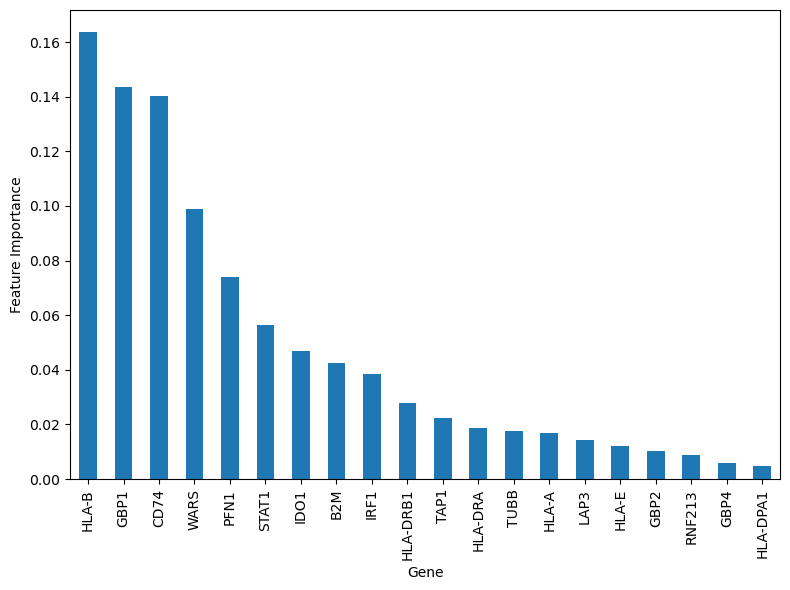

In [47]:
# Create a series containing feature importances from the model and feature names from the training data
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Plot the 20 most important genes
plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(20).plot(kind="bar")
plt.ylabel("Feature Importance")
plt.xlabel("Gene")
plt.tight_layout()

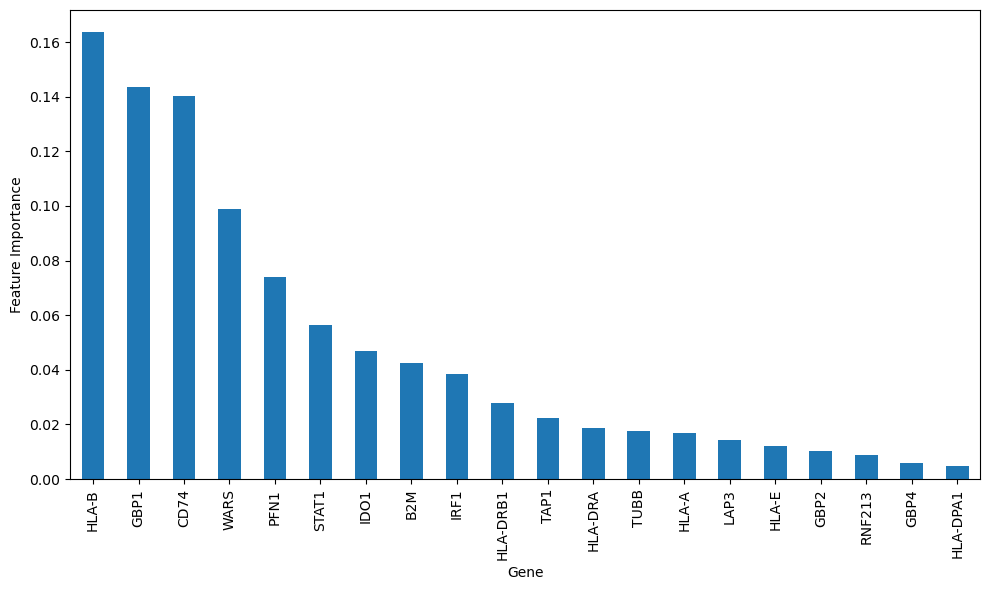

Plot saved to: C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png


In [48]:
# Save the feature importance plot
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance series
importances = pd.Series(
    best_rf.feature_importances_,
    index=adata_hvg.var_names
)

# Select top 20 genes
top20 = importances.sort_values(ascending=False).head(20)

# Figure axis
fig, ax = plt.subplots(figsize=(10, 6))

top20.plot(kind="bar", ax=ax)

ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Plot saved to: {output_path}")

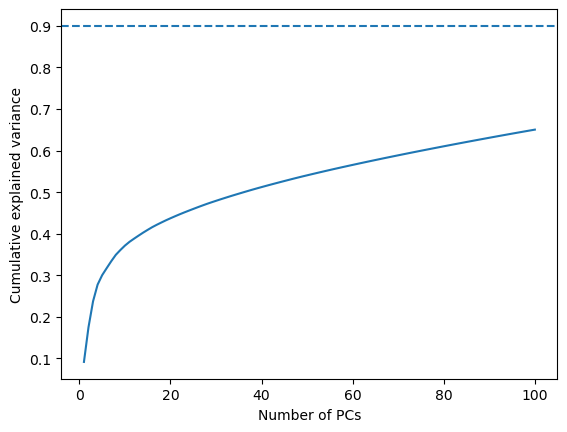

[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  15.1s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  15.9s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  15.5s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=8, n_estimators=100; total time=  16.0s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=300; total time=  15.4s
[CV] END max_depth=6, max_features=0.2, min_samples_leaf=4, min_samples_split=2, n_estimators=400; total time= 1.2min
[CV] END max_depth=12, max_features=log2, min_sam

In [61]:
# 2. Idea: Train a Random Forest model using principal components
# computed from the highly variable genes

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Perform PCA first
sc.pp.pca(adata_hvg, n_comps=100)

# Get the explained variance ratio of each PC
variance_ratio = adata_hvg.uns["pca"]["variance_ratio"]

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(variance_ratio)

# Plot the cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.axhline(y=0.90, linestyle="--")
plt.show()

In [49]:
# 2. Idea: Train a Random Forest model using principal components
# computed from the highly variable genes
import scanpy as sc
# Perform PCA on the HVG expression data and retain the first 50 principal components
sc.pp.pca(adata_hvg, n_comps=50)

In [50]:
# Use the first 50 principal components as input features for the model
X = adata_hvg.obsm["X_pca"][:, :50]

In [51]:
# Split the data into training (80%) and test (20%) sets,
# while preserving the proportion of each condition/class in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter values to search
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 6, 9, 12],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ["sqrt", "log2", 0.2, 0.5]
}

# Create Random Forest classifier
rf = RandomForestClassifier(
    random_state=42,
    n_jobs= 3
)

# Randomized search
rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,              # Number of random combinations to evaluate
    cv=3,
    scoring='accuracy',
    n_jobs=3,
    random_state=42,
    verbose=2
)

# Fit the model
rand_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(rand_search.best_params_)

# Best cross-validation score
print(f"Best CV accuracy: {rand_search.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 12}
Best CV accuracy: 0.9780


In [53]:
# Extract the best-performing Random Forest model from the randomized search
best_rf = rand_search.best_estimator_

# Get the importance score of each PC used by the model
pc_importance = best_rf.feature_importances_

# Print the importance scores of all PCs
print(pc_importance)

[0.25969835 0.39893589 0.14682525 0.02067571 0.01848228 0.01476189
 0.0059022  0.0070888  0.01182205 0.00705493 0.00765434 0.00284775
 0.00427076 0.00391919 0.00266754 0.0026176  0.00406124 0.00379944
 0.00233862 0.00279994 0.00269376 0.00223775 0.0070908  0.00185454
 0.00265683 0.00245107 0.00251866 0.00271577 0.00725503 0.0017302
 0.00226749 0.00238835 0.00295913 0.00163233 0.00167294 0.00188325
 0.00206577 0.00387068 0.00177167 0.0017924  0.00160027 0.00162786
 0.00166349 0.0015784  0.00118397 0.00136577 0.00185967 0.00230646
 0.00149309 0.00158882]


In [54]:
# Check if the model is overfitting
from sklearn.metrics import accuracy_score

# Get the best Random Forest model
best_rf = rand_search.best_estimator_

# Calculate accuracy on the training data
train_pred = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Calculate accuracy on the test data
test_pred = best_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

# Print training and test accuracy
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

# Print the best cross-validation accuracy
print(rand_search.best_score_)

Training accuracy: 0.9852
Test accuracy:     0.9771
0.9780043006141655


In [55]:
# Get the gene loadings for each principal component
loadings = adata_hvg.varm["PCs"]

In [56]:
# Calculate a score for each gene based on the PC importances
gene_scores = np.abs(loadings) @ pc_importance

In [57]:
import pandas as pd

# Create a table with the score of each gene
gene_scores = pd.Series(
    gene_scores,
    index=adata_hvg.var_names
)

# Sort the genes according to their score
top_genes = gene_scores.sort_values(ascending=False)

# Show the top 20 most important genes
print(top_genes.head(20))

gene_symbol
GBP1        0.166239
HLA-B       0.153886
CD74        0.143419
WARS        0.127125
STAT1       0.125474
IDO1        0.123385
IRF1        0.111240
HLA-DRA     0.100918
B2M         0.099142
LAP3        0.098737
HLA-DRB1    0.096746
RNF213      0.089039
TAP1        0.088402
GBP2        0.087314
HLA-E       0.087038
PMEPA1      0.085941
GBP4        0.085323
NNMT        0.084724
HLA-A       0.084672
ICAM1       0.082529
dtype: float64


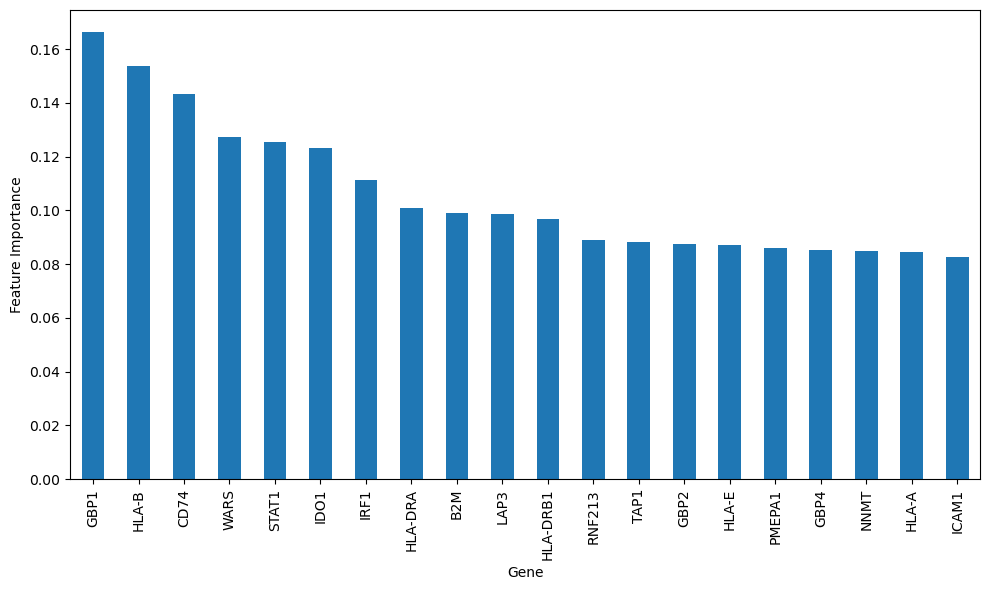

In [58]:
# Save the top 20 most important genes as a plot
import pandas as pd
import matplotlib.pyplot as plt

# Select the 20 genes with the highest scores
top20 = gene_scores.sort_values(ascending=False).head(20)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Make a bar plot of the top 20 genes
top20.plot(kind="bar", ax=ax)

# Add labels to the plot
ax.set_ylabel("Feature Importance")
ax.set_xlabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()

# Save the figure
output_path = r"C:\Users\Deniz Korkmazel\OneDrive\Documents\Uni Heidelberg Molekulare Biotechnologie\Master 2_semester\ML_AI_Seminar\Task_1_top20.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

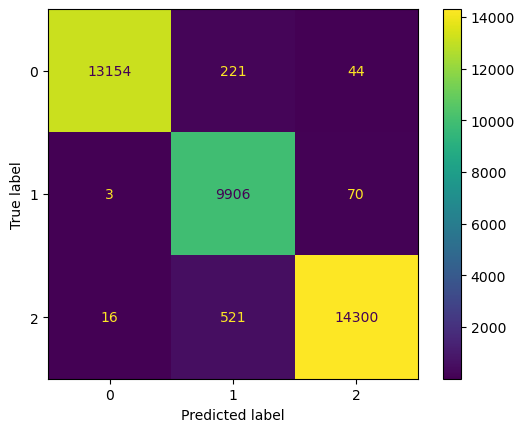

In [59]:
# Predict the conditions for the test data
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [60]:
# Check which class labels are used
print(np.unique(y))

['Co-culture' 'Control' 'IFNγ']
